얼굴 개수: 1


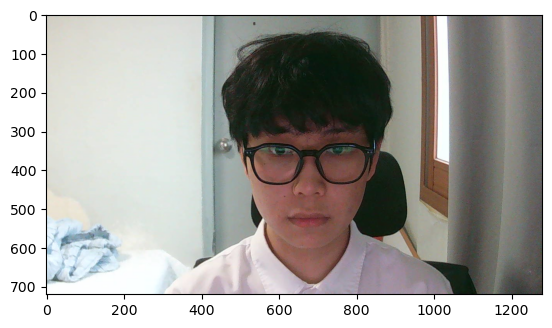

In [3]:
import cv2
import dlib
import numpy as np
from matplotlib import pyplot as plt

# 이미지 불러오기
img_path = 'my_face1.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 마스크 이미지 불러오기 (투명 배경 유지)
sticker = cv2.imread('mask.png', cv2.IMREAD_UNCHANGED)

# 얼굴 검출기 불러오기
detector = dlib.get_frontal_face_detector()

# 얼굴 검출
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
dlib_rects = detector(img_rgb, 1)

print(f'얼굴 개수: {len(dlib_rects)}')

plt.imshow(img_rgb)
plt.show()

rectangles[[(526, 277) (847, 598)]]


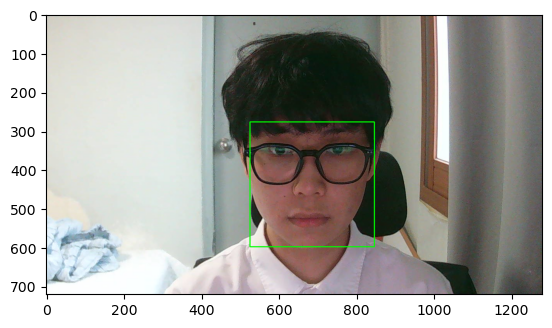

In [4]:
img_show = img_rgb.copy()

print(dlib_rects)

for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2)

plt.imshow(img_show)
plt.show()

In [6]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-04-20 06:02:29--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-20 06:02:29--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  16.3MB/s    in 4.6s    

2026-04-20 06:02:35 (13.2 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [5]:
import os

model_path = os.path.join(os.getenv('HOME'), 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

print(len(list_landmarks[0]))

68


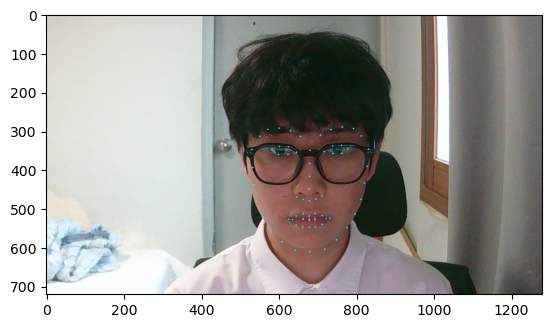

(679, 480)


In [6]:
img_show = img_rgb.copy()

for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

plt.imshow(img_show)
plt.show()

print(list_landmarks[0][33])

In [13]:
# 얼굴 박스 좌표
face_left = dlib_rects[0].left()
face_top = dlib_rects[0].top()

sticker_width = face_width * 2
sticker_height = int(sticker.shape[0] * sticker_width / sticker.shape[1])

sticker_resized = cv2.resize(sticker, (sticker_width, sticker_height))

# 얼굴 중심 기준으로 위치 계산
face_center_x = dlib_rects[0].left() + face_width // 2
face_center_y = dlib_rects[0].top() + face_height // 2

x1 = face_center_x - sticker_width // 2
y1 = face_center_y - sticker_height // 2

x2 = x1 + sticker_width
y2 = y1 + sticker_height

print(f'스티커 크기: {sticker_width} x {sticker_height}')
print(f'붙일 위치: ({x1}, {y1})')

스티커 크기: 642 x 774
붙일 위치: (365, 50)


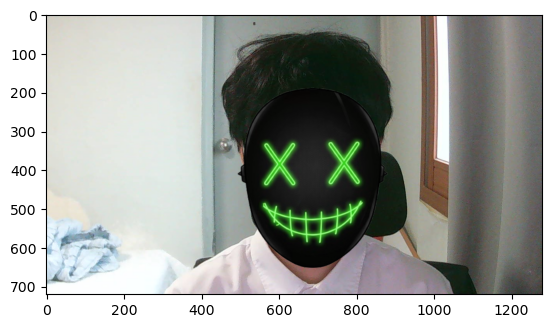

In [14]:
img_result = img_rgb.copy()

# 스티커 붙일 영역
x2 = x1 + sticker_width
y2 = y1 + sticker_height

# 이미지 범위 벗어나면 자르기
if x1 < 0: x1 = 0
if y1 < 0: y1 = 0
if x2 > img_result.shape[1]: x2 = img_result.shape[1]
if y2 > img_result.shape[0]: y2 = img_result.shape[0]

# 스티커 알파채널 분리
sticker_crop = sticker_resized[:y2-y1, :x2-x1]
alpha = sticker_crop[:, :, 3] / 255.0

# 스티커 붙이기
for c in range(3):
    img_result[y1:y2, x1:x2, c] = (
        alpha * sticker_crop[:, :, c] +
        (1 - alpha) * img_result[y1:y2, x1:x2, c]
    )

plt.imshow(img_result)
plt.show()

In [15]:
## 첫번쨰 사진을 했을땐 얼굴 인식이 안되서 두번쨰 얼굴을 가까이서 찍었을경우로 다시 했더니 얼굴인식됨
## 스티커 위치랑 크기 이상해서 다시 계산수 수정해 붙임

In [17]:
# 2번쨰 수정sticker_width = face_width * 2
# sticker_height = int(sticker.shape[0] * sticker_width / sticker.shape[1])

# sticker_resized = cv2.resize(sticker, (sticker_width, sticker_height))

# # 얼굴 중심 기준으로 위치 계산
# face_center_x = face_left + face_width // 2
# face_center_y = face_top + face_height // 2

# x1 = face_center_x - sticker_width // 2
# y1 = face_center_y - sticker_height // 2

# #3번쨰 수정
# face_center_x = dlib_rects[0].left() + face_width // 2
# face_center_y = dlib_rects[0].top() + face_height // 2

# x1 = face_center_x - sticker_width // 2
# y1 = face_center_y - sticker_height // 2

# x2 = x1 + sticker_width
# y2 = y1 + sticker_height

In [ ]:
##화면이 어두웠을때

얼굴 개수: 1


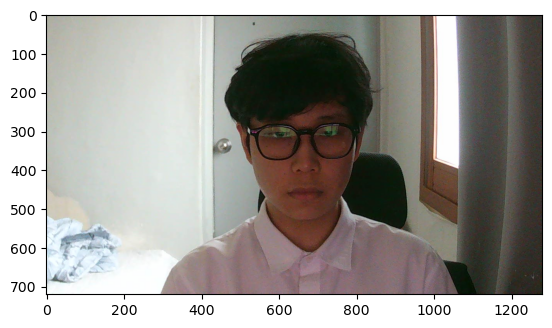

In [19]:
# 이미지 불러오기
img_path = 'my_face2.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 마스크 이미지 불러오기 (투명 배경 유지)
sticker = cv2.imread('mask.png', cv2.IMREAD_UNCHANGED)

# 얼굴 검출기 불러오기
detector = dlib.get_frontal_face_detector()

# 얼굴 검출
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
dlib_rects = detector(img_rgb, 1)

print(f'얼굴 개수: {len(dlib_rects)}')

plt.imshow(img_rgb)
plt.show()

In [ ]:
#인식됨

In [ ]:
#멀리 떨어져 찍었을떄

얼굴 개수: 0


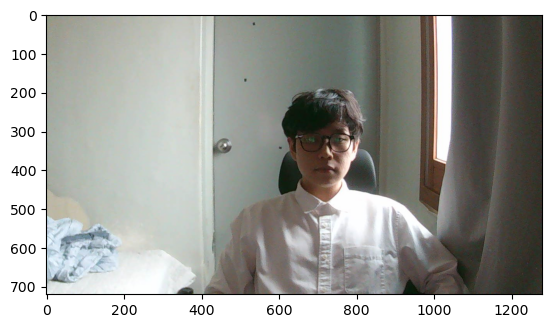

In [20]:
# 이미지 불러오기
img_path = 'my_face3.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 마스크 이미지 불러오기 (투명 배경 유지)
sticker = cv2.imread('mask.png', cv2.IMREAD_UNCHANGED)

# 얼굴 검출기 불러오기
detector = dlib.get_frontal_face_detector()

# 얼굴 검출
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
dlib_rects = detector(img_rgb, 1)

print(f'얼굴 개수: {len(dlib_rects)}')

plt.imshow(img_rgb)
plt.show()

In [ ]:
#인식안된다 => dlib의 얼굴 검출기는 얼굴 크기가 일정 이상이여야 하기 떄문에 그것보다 얼굴 픽셀수가 적으면 인식이 안됨

In [ ]:
##각도가 다를때

얼굴 개수: 0


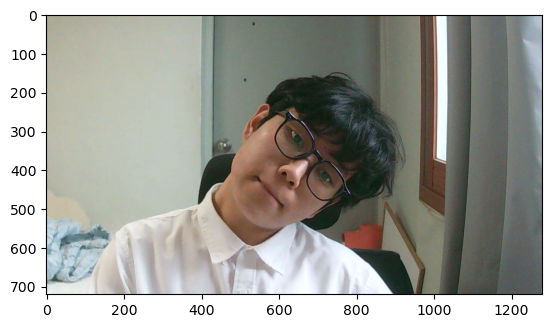

In [21]:
# 이미지 불러오기
img_path = 'my_face4.jpg'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 마스크 이미지 불러오기 (투명 배경 유지)
sticker = cv2.imread('mask.png', cv2.IMREAD_UNCHANGED)

# 얼굴 검출기 불러오기
detector = dlib.get_frontal_face_detector()

# 얼굴 검출
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
dlib_rects = detector(img_rgb, 1)

print(f'얼굴 개수: {len(dlib_rects)}')

plt.imshow(img_rgb)
plt.show()

In [ ]:
##내가 설치한 dlib는 정면 얼굴 전용이기 때문에 각도가 살짝 틀어지면 인식이 안됨

In [ ]:
# 회고: 사람이 여러명일 경우 나 아니면 선글라스 나 마스크를 쓴상태로 못해본게 아쉽고 여기서 제공해준 dlib 얼국 검출기는 한계가 명확해서 다른 검출기를 사용해보고 싶은마은이 든다